In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%writefile cnn_model.py
import torch
import torch.nn as nn

class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super(CNNFeatureExtractor, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 8 * 8, 128)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Writing cnn_model.py


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from cnn_model import CNNFeatureExtractor

class CNNBaseline(nn.Module):
    def __init__(self, feature_extractor):
        super(CNNBaseline, self).__init__()
        self.features = feature_extractor
        self.classifier = nn.Linear(128, 2)

    def forward(self, x):
        batch_size, seq_len, c, h, w = x.size()
        x = x.view(batch_size * seq_len, c, h, w)
        x = self.features(x)
        x = self.classifier(x)
        x = x.view(batch_size, seq_len, -1)
        x = x.mean(dim=1)
        return x

data_dir = "/content/drive/MyDrive/processed_data/processed_data"

X_train = np.load(f"{data_dir}/X_train.npy")
y_train = np.load(f"{data_dir}/y_train.npy")
X_val = np.load(f"{data_dir}/X_val.npy")
y_val = np.load(f"{data_dir}/y_val.npy")

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 1, 4, 2, 3)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).permute(0, 1, 4, 2, 3)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_model = CNNFeatureExtractor()
model = CNNBaseline(base_model).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss/len(train_loader):.4f} Acc: {train_correct/train_total:.4f} | Val Loss: {val_loss/len(val_loader):.4f} Acc: {val_correct/val_total:.4f}")

Epoch 1/10 - Train Loss: 3.8403 Acc: 0.6389 | Val Loss: 3.3058 Acc: 0.5000
Epoch 2/10 - Train Loss: 0.1861 Acc: 0.9325 | Val Loss: 0.2401 Acc: 0.8704
Epoch 3/10 - Train Loss: 0.0322 Acc: 0.9881 | Val Loss: 0.0643 Acc: 0.9907
Epoch 4/10 - Train Loss: 0.0039 Acc: 1.0000 | Val Loss: 0.0063 Acc: 1.0000
Epoch 5/10 - Train Loss: 0.0023 Acc: 1.0000 | Val Loss: 0.0020 Acc: 1.0000
Epoch 6/10 - Train Loss: 0.0023 Acc: 1.0000 | Val Loss: 0.0016 Acc: 1.0000
Epoch 7/10 - Train Loss: 0.0015 Acc: 1.0000 | Val Loss: 0.0014 Acc: 1.0000
Epoch 8/10 - Train Loss: 0.0013 Acc: 1.0000 | Val Loss: 0.0012 Acc: 1.0000
Epoch 9/10 - Train Loss: 0.0011 Acc: 1.0000 | Val Loss: 0.0010 Acc: 1.0000
Epoch 10/10 - Train Loss: 0.0010 Acc: 1.0000 | Val Loss: 0.0009 Acc: 1.0000


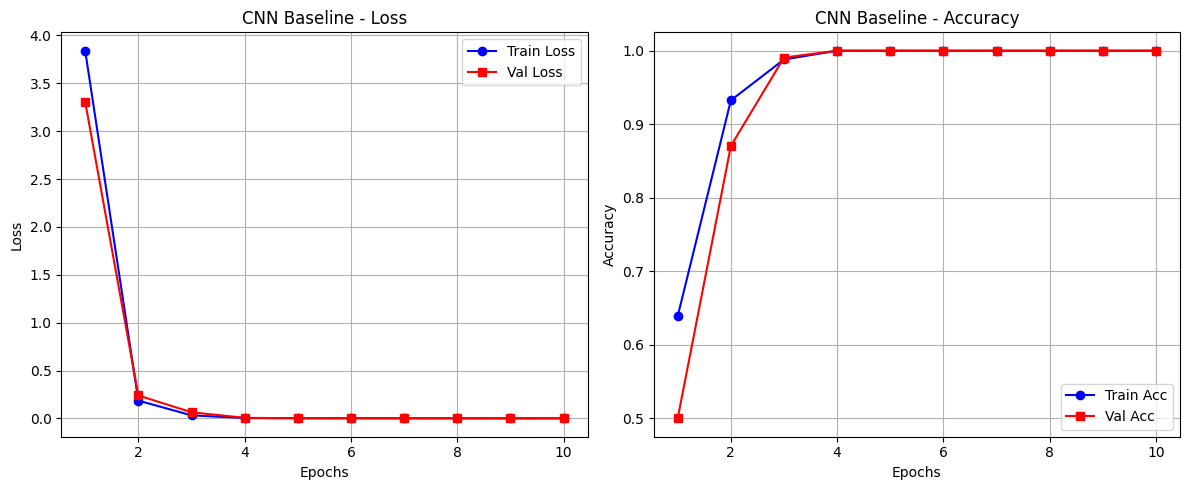

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, 11)
train_loss = [3.8403, 0.1861, 0.0322, 0.0039, 0.0023, 0.0023, 0.0015, 0.0013, 0.0011, 0.0010]
val_loss = [3.3058, 0.2401, 0.0643, 0.0063, 0.0020, 0.0016, 0.0014, 0.0012, 0.0010, 0.0009]
train_acc = [0.6389, 0.9325, 0.9881, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
val_acc = [0.5000, 0.8704, 0.9907, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(epochs, train_loss, label='Train Loss', marker='o', color='blue')
ax1.plot(epochs, val_loss, label='Val Loss', marker='s', color='red')
ax1.set_title('CNN Baseline - Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_acc, label='Train Acc', marker='o', color='blue')
ax2.plot(epochs, val_acc, label='Val Acc', marker='s', color='red')
ax2.set_title('CNN Baseline - Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('cnn_metrics.png')
plt.show()